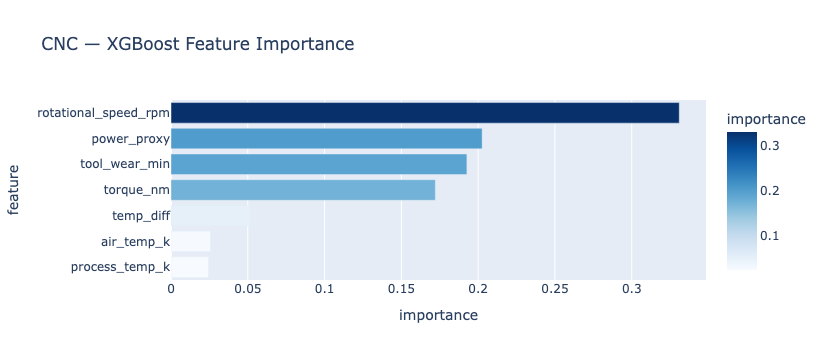

In [1]:
import pandas as pd
import plotly.express as px
import pickle

with open("../../models/cnc_model.pkl", "rb") as f:
    cnc_model = pickle.load(f)

features = ["air_temp_k", "process_temp_k", "rotational_speed_rpm",
            "torque_nm", "tool_wear_min", "temp_diff", "power_proxy"]

importance = pd.DataFrame({
    "feature": features,
    "importance": cnc_model.feature_importances_
}).sort_values("importance", ascending=True)

fig = px.bar(importance, x="importance", y="feature",
             orientation="h",
             title="CNC — XGBoost Feature Importance",
             color="importance",
             color_continuous_scale="Blues")
fig.show()

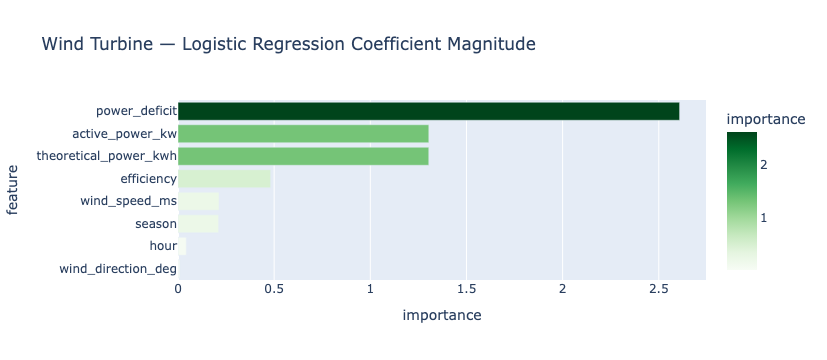

In [3]:
with open("../../models/wind_model.pkl", "rb") as f:
    wind_model = pickle.load(f)

# Pull feature names directly from the trained model
wind_features = list(wind_model.feature_names_in_)
wind_coefs = abs(wind_model.coef_[0])

wind_importance = pd.DataFrame({
    "feature": wind_features,
    "importance": wind_coefs
}).sort_values("importance", ascending=True)

fig_wind = px.bar(wind_importance, x="importance", y="feature",
                  orientation="h",
                  title="Wind Turbine — Logistic Regression Coefficient Magnitude",
                  color="importance",
                  color_continuous_scale="Greens")
fig_wind.show()

In [4]:
import plotly.io as pio

pio.write_image(fig, "../../reports/figures/cnc_feature_importance.png")
pio.write_image(fig_wind, "../../reports/figures/wind_feature_importance.png")
print("Saved both charts.")

NameError: name 'fig' is not defined

In [3]:
import plotly.io as pio
import plotly.express as px
import pandas as pd
import pickle
import os

os.makedirs("../../reports/figures", exist_ok=True)

# CNC
with open("../../models/cnc_model.pkl", "rb") as f:
    cnc_model = pickle.load(f)

cnc_features = ["air_temp_k", "process_temp_k", "rotational_speed_rpm",
                "torque_nm", "tool_wear_min", "temp_diff", "power_proxy"]

cnc_importance = pd.DataFrame({
    "feature": cnc_features,
    "importance": cnc_model.feature_importances_
}).sort_values("importance", ascending=True)

fig_cnc = px.bar(cnc_importance, x="importance", y="feature",
                 orientation="h",
                 title="CNC — XGBoost Feature Importance",
                 color="importance",
                 color_continuous_scale="Blues")

# Wind
with open("../../models/wind_model.pkl", "rb") as f:
    wind_model = pickle.load(f)

wind_features = list(wind_model.feature_names_in_)
wind_importance = pd.DataFrame({
    "feature": wind_features,
    "importance": abs(wind_model.coef_[0])
}).sort_values("importance", ascending=True)

fig_wind = px.bar(wind_importance, x="importance", y="feature",
                  orientation="h",
                  title="Wind Turbine — Logistic Regression Coefficient Magnitude",
                  color="importance",
                  color_continuous_scale="Greens")

# Save both
pio.write_image(fig_cnc, "../../reports/figures/cnc_feature_importance.png")
pio.write_image(fig_wind, "../../reports/figures/wind_feature_importance.png")
print("Both charts saved.")

Both charts saved.
